In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import statsmodels.formula.api as smf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, LeaveOneOut, cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_excel('./datasets/swatch.xlsx')
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con)
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


In [4]:
cols = df.columns
cols_GD = df.columns[3]
cols_HD = df.columns[4]

In [5]:
# 로그 변환
df['log_GD'] = np.log(df[cols_GD])
df['log_HD'] = np.log(df[cols_HD])
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),log_GD,log_HD
0,ACF25-01,105.20,1150,320,280,5.768321,5.634790
1,ACF25-02,99.30,1450,470,220,6.152733,5.393628
2,ACF25-03,119.70,1150,1150,550,7.047517,6.309918
3,ACF25-04,110.40,1300,850,850,6.745236,6.745236
4,ACF25-05,103.44,1016,470,580,6.152733,6.363028
5,ACF25-06,122.83,1080,20,140,2.995732,4.941642
6,ACF25-07,154.49,1139,380,10,5.940171,2.302585
7,ACF25-08,140.00,1300,20,5,2.995732,1.609438
8,ACF25-09,130.00,2197,50,5,3.912023,1.609438


# Polynomial + Ridge

In [6]:
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
model

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('ridge', Ridge())])

In [7]:
loo = LeaveOneOut()

X = df[[cols[1], cols[2]]].values
y = df[cols_GD].values

param_grid = {'ridge__alpha': np.logspace(-3, 5, 200)}
grid = GridSearchCV(model, param_grid=param_grid, cv=loo, scoring='neg_mean_squared_error')
grid.fit(X, y)

GridSearchCV(cv=LeaveOneOut(),
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': array([1.00000000e-03, 1.09698580e-03, 1.20337784e-03, 1.32008840e-03,
       1.44811823e-03, 1.58856513e-03, 1.74263339e-03, 1.91164408e-03,
       2.09704640e-03, 2.30043012e-03, 2.52353917e-03...
       1.18953407e+04, 1.30490198e+04, 1.43145894e+04, 1.57029012e+04,
       1.72258597e+04, 1.88965234e+04, 2.07292178e+04, 2.27396575e+04,
       2.49450814e+04, 2.73644000e+04, 3.00183581e+04, 3.29297126e+04,
       3.61234270e+04, 3.96268864e+04, 4.34701316e+04, 4.76861170e+04,
       5.23109931e+04, 5.73844165e+04, 6.29498899e+04, 6.90551352e+04,
       7.57525026e+04, 8.30994195e+04, 9.11588830e+04, 1.00000000e+05])},
             scoring='neg_mean_squared_error')

In [42]:
best_model = grid.best_estimator_
best_alpha = grid.best_params_['ridge__alpha']
best_alpha

41.987070844439145

In [43]:
feature_names = best_model.named_steps['poly'].get_feature_names_out(['평량', 'BET'])
coefs = best_model.named_steps['ridge'].coef_
intercept = best_model.named_steps['ridge'].intercept_

print(f"y = {intercept:.2f}")
for name, coef in zip(feature_names, coefs):
    print(f" + {coef:.2f} * z({name})")

y = 414.44
 + -16.12 * z(평량)
 + -13.35 * z(BET)
 + -16.07 * z(평량^2)
 + -19.07 * z(평량 BET)
 + -14.70 * z(BET^2)


# 평가

In [44]:
scores = cross_val_score(best_model, X, y, cv=loo, scoring='neg_mean_squared_error')
rmse = np.sqrt(-scores.mean())
rmse

403.97790181721734

In [45]:
loo_pred = cross_val_predict(best_model, X, y, cv=loo)
loo_rmse = np.sqrt(mean_squared_error(y, loo_pred))
loo_r2 = r2_score(y, loo_pred)

print("LOO predictions:", loo_pred)
print("LOOCV RMSE:", loo_rmse)
print("LOOCV R2:", loo_r2)

LOO predictions: [494.2892802  447.68329776 339.92718243 382.60850339 492.02698795
 499.28702552 301.32441512 435.85162648 442.31629232]
LOOCV RMSE: 403.97790181721734
LOOCV R2: -0.23321234398909851


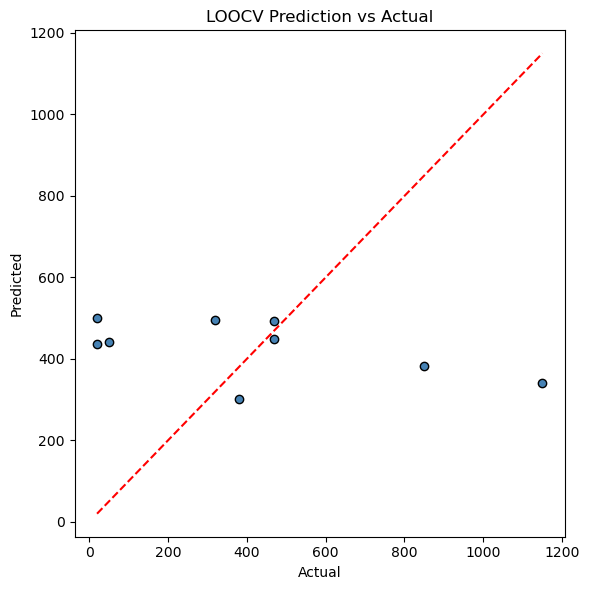

In [46]:
plt.figure(figsize=(6,6))

plt.scatter(y, loo_pred, color='steelblue', edgecolors='black')

# 기준선
min_val = min(y.min(), loo_pred.min())
max_val = max(y.max(), loo_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LOOCV Prediction vs Actual")

plt.tight_layout()
plt.show()

y = 293.33
 + -51.14 * z(평량)
 + -19.59 * z(BET)
 + -54.55 * z(평량^2)
 + -36.12 * z(평량 BET)
 + -19.70 * z(BET^2)
LOO predictions: [464.32531291 481.47566575 303.10296713 291.09433923 430.88341074
 359.62961173  94.10510878 203.28110254 -51.51839039]
LOOCV RMSE: 257.279645561426
LOOCV R2: 0.18787356801592703


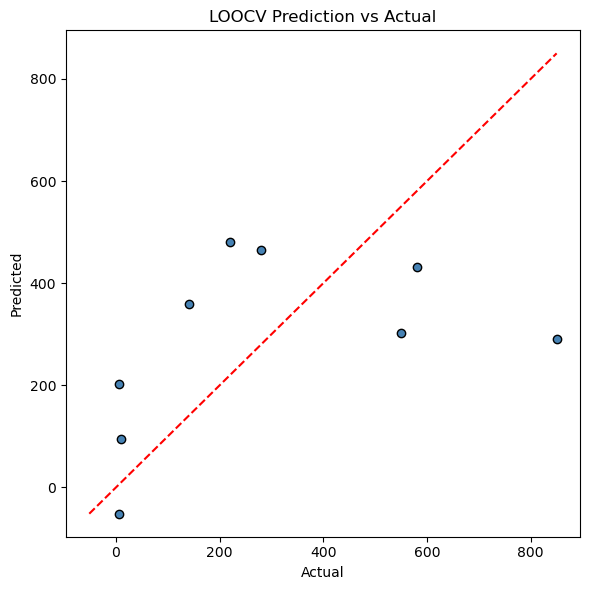

In [47]:
# HD 방호성능
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])
loo = LeaveOneOut()

X = df[[cols[1], cols[2]]].values
y = df[cols_HD].values

param_grid = {'ridge__alpha': np.logspace(-3, 5, 200)}
grid = GridSearchCV(model, param_grid=param_grid, cv=loo, scoring='neg_mean_squared_error')
grid.fit(X, y)

best_model = grid.best_estimator_
best_alpha = grid.best_params_['ridge__alpha']
best_alpha

feature_names = best_model.named_steps['poly'].get_feature_names_out(['평량', 'BET'])
coefs = best_model.named_steps['ridge'].coef_
intercept = best_model.named_steps['ridge'].intercept_

print(f"y = {intercept:.2f}")
for name, coef in zip(feature_names, coefs):
    print(f" + {coef:.2f} * z({name})")

scores = cross_val_score(best_model, X, y, cv=loo, scoring='neg_mean_squared_error')
rmse = np.sqrt(-scores.mean())
# scores = cross_val_score(best_model, X, y, cv=loo, scoring='neg_mean_squared_error')
# rmse = np.sqrt(-scores.mean())

loo_pred = cross_val_predict(best_model, X, y, cv=loo)
loo_rmse = np.sqrt(mean_squared_error(y, loo_pred))
loo_r2 = r2_score(y, loo_pred)

print("LOO predictions:", loo_pred)
print("LOOCV RMSE:", loo_rmse)
print("LOOCV R2:", loo_r2)

plt.figure(figsize=(6,6))

plt.scatter(y, loo_pred, color='steelblue', edgecolors='black')

# 기준선
min_val = min(y.min(), loo_pred.min())
max_val = max(y.max(), loo_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LOOCV Prediction vs Actual")

plt.tight_layout()
plt.show()

# 유의성 검사

In [8]:
import statsmodels.formula.api as smf

pairs = [
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(GD) 24h(Con)'),
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(HD) 24h(Con)'),
    ('평량(g/m2)', 'BET(m2/g)', 'log_GD'),
    ('평량(g/m2)', 'BET(m2/g)', 'log_HD'),
]

In [9]:
scaler = StandardScaler()
df_scaled = df.copy()
# 평량과 BET 컬럼만 추출하여 스케일링합니다.
# df_scaled[[x1_col, x2_col]] = scaler.fit_transform(df[[x1_col, x2_col]])

In [50]:
# # GD방호성능 Regression
# x1_col, x2_col, y_col = pairs[0]

# formula = (
#     f'Q("{y_col}") ~ '
#     f'Q("{x1_col}") + Q("{x2_col}") + '
#     f'I(Q("{x1_col}")**2) + I(Q("{x2_col}")**2) + '
#     f'Q("{x1_col}"):Q("{x2_col}")'
# )
# print(formula)

# model_GD = smf.ols(formula, data = df)

# result_GD = model_GD.fit()
# pred_GD = result_GD.predict()
# print('pred_GD:', pred_GD)
# print(result_GD.summary())

# # Pred vs. Observed
# fig, ax = plt.subplots()

# true_y_GD = df[y_col]

# ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# # 기준선
# ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
#         linestyle='--', color='red')
# # for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
# #     ax.annotate(samples[idx], (xi, yi),
# #                 fontsize=7, xytext=(3, 3), textcoords='offset points')

# ax.set_xlabel('Fitted')
# ax.set_ylabel('Observed')
# ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

# plt.tight_layout()
# plt.show()

Q("SWATCH(GD) 24h(Con)") ~ Q("평량(g/m2)") + Q("BET(m2/g)") + I(Q("평량(g/m2)")**2) + I(Q("BET(m2/g)")**2) + Q("평량(g/m2)"):Q("BET(m2/g)")
pred_GD: [490.54644726 624.43870016 534.1937036  549.27599556 419.08306666
 546.69343191 232.53445981 296.92938837  36.30480667]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(GD) 24h(Con)")   R-squared:                       0.243
Model:                                  OLS   Adj. R-squared:                 -1.018
Method:                       Least Squares   F-statistic:                    0.1929
Date:                      Fri, 01 May 2026   Prob (F-statistic):              0.946
Time:                              13:46:19   Log-Likelihood:                -64.585
No. Observations:                         9   AIC:                             141.2
Df Residuals:                             3   BIC:                             142.4
Df Model:                                 5              

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


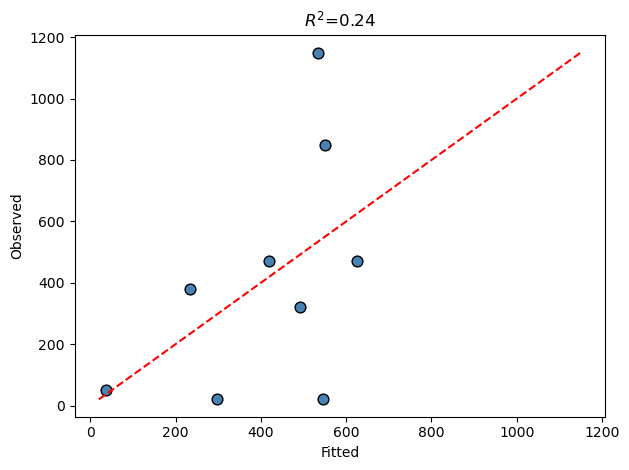

In [10]:
# GD방호성능 Regression 스케일링
x1_col, x2_col, y_col = pairs[0]
df_scaled[[x1_col, x2_col]] = scaler.fit_transform(df[[x1_col, x2_col]])

formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col}") + Q("{x2_col}") + '
    f'I(Q("{x1_col}")**2) + I(Q("{x2_col}")**2) + '
    f'Q("{x1_col}"):Q("{x2_col}")'
)
print(formula)

model_GD = smf.ols(formula, data = df_scaled)

result_GD = model_GD.fit()
pred_GD = result_GD.predict()
print('pred_GD:', pred_GD)
print(result_GD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_GD = df_scaled[y_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

plt.tight_layout()
plt.show()

Q("SWATCH(HD) 24h(Con)") ~ Q("평량(g/m2)") + Q("BET(m2/g)") + I(Q("평량(g/m2)")**2) + I(Q("BET(m2/g)")**2) + Q("평량(g/m2)"):Q("BET(m2/g)")
pred_HD: [478.72387903 371.33089403 394.92140528 431.03278199 503.88563183
 359.68117772 -97.74609481 200.73619357  -2.56586865]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(HD) 24h(Con)")   R-squared:                       0.501
Model:                                  OLS   Adj. R-squared:                 -0.331
Method:                       Least Squares   F-statistic:                    0.6025
Date:                      Fri, 01 May 2026   Prob (F-statistic):              0.711
Time:                              13:46:28   Log-Likelihood:                -60.530
No. Observations:                         9   AIC:                             133.1
Df Residuals:                             3   BIC:                             134.2
Df Model:                                 5              

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


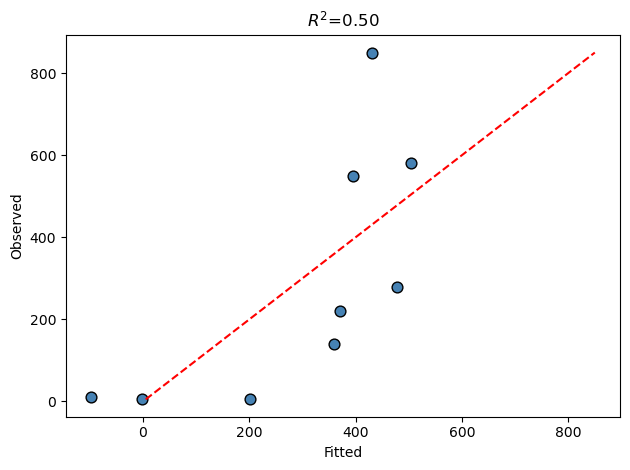

In [11]:
# HD방호성능 Regression 스케일링
x1_col, x2_col, y_col = pairs[1]
df_scaled[[x1_col, x2_col]] = scaler.fit_transform(df[[x1_col, x2_col]])

formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col}") + Q("{x2_col}") + '
    f'I(Q("{x1_col}")**2) + I(Q("{x2_col}")**2) + '
    f'Q("{x1_col}"):Q("{x2_col}")'
)
print(formula)

model_HD = smf.ols(formula, data = df_scaled)

result_HD = model_HD.fit()
pred_HD = result_HD.predict()
print('pred_HD:', pred_HD)
print(result_HD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_HD = df_scaled[y_col]

ax.scatter(pred_HD, true_y_HD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_HD.min(), true_y_HD.max()], [true_y_HD.min(), true_y_HD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_HD.rsquared:.2f}')

plt.tight_layout()
plt.show()

Q("log_GD") ~ Q("평량(g/m2)") + Q("BET(m2/g)") + I(Q("평량(g/m2)")**2) + I(Q("BET(m2/g)")**2) + Q("평량(g/m2)"):Q("BET(m2/g)")
pred_GD: [5.99510323 6.8933567  4.9165968  5.46643978 6.20521115 4.90870543
 5.31985349 4.16072134 3.84421084]
                            OLS Regression Results                            
Dep. Variable:            Q("log_GD")   R-squared:                       0.384
Model:                            OLS   Adj. R-squared:                 -0.643
Method:                 Least Squares   F-statistic:                    0.3736
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.842
Time:                        13:46:33   Log-Likelihood:                -14.134
No. Observations:                   9   AIC:                             40.27
Df Residuals:                       3   BIC:                             41.45
Df Model:                           5                                         
Covariance Type:            nonrobust                    

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


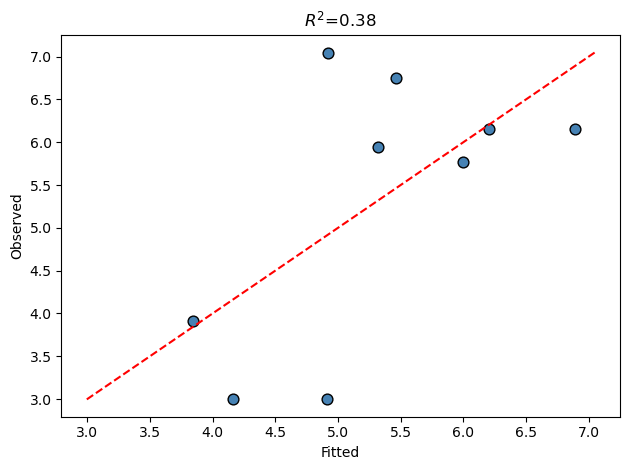

In [12]:
# GD방호성능 Regression + log
x1_col, x2_col, y_col = pairs[2]
df_scaled[[x1_col, x2_col]] = scaler.fit_transform(df[[x1_col, x2_col]])

formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col}") + Q("{x2_col}") + '
    f'I(Q("{x1_col}")**2) + I(Q("{x2_col}")**2) + '
    f'Q("{x1_col}"):Q("{x2_col}")'
)
print(formula)

model_GD = smf.ols(formula, data = df_scaled)

result_GD = model_GD.fit()
pred_GD = result_GD.predict()
print('pred_GD:', pred_GD)
print(result_GD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_GD = df_scaled[y_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

plt.tight_layout()
plt.show()

Q("log_HD") ~ Q("평량(g/m2)") + Q("BET(m2/g)") + I(Q("평량(g/m2)")**2) + I(Q("BET(m2/g)")**2) + Q("평량(g/m2)"):Q("BET(m2/g)")
pred_HD: [5.94654034 5.97758594 5.55052778 5.4406658  6.31442221 5.84845387
 1.88692404 2.37524198 1.56934125]
                            OLS Regression Results                            
Dep. Variable:            Q("log_HD")   R-squared:                       0.879
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     4.363
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.128
Time:                        13:46:40   Log-Likelihood:                -9.4491
No. Observations:                   9   AIC:                             30.90
Df Residuals:                       3   BIC:                             32.08
Df Model:                           5                                         
Covariance Type:            nonrobust                    

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


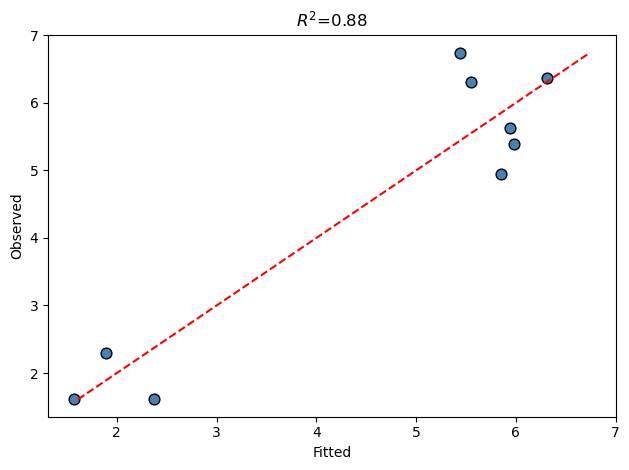

In [13]:
# HD방호성능 Regression + log
x1_col, x2_col, y_col = pairs[3]
df_scaled[[x1_col, x2_col]] = scaler.fit_transform(df[[x1_col, x2_col]])

formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col}") + Q("{x2_col}") + '
    f'I(Q("{x1_col}")**2) + I(Q("{x2_col}")**2) + '
    f'Q("{x1_col}"):Q("{x2_col}")'
)
print(formula)

model_HD = smf.ols(formula, data = df_scaled)

result_HD = model_HD.fit()
pred_HD = result_HD.predict()
print('pred_HD:', pred_HD)
print(result_HD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_HD = df_scaled[y_col]

ax.scatter(pred_HD, true_y_HD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_HD.min(), true_y_HD.max()], [true_y_HD.min(), true_y_HD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_HD.rsquared:.2f}')

plt.tight_layout()
plt.show()

# y 로그변환 후 OLS

In [14]:
df

,Sample,평량(g/m2),BET(m2/g),SWATCH(GD) 24h(Con),SWATCH(HD) 24h(Con),log_GD,log_HD
0,ACF25-01,105.20,1150,320,280,5.768321,5.634790
1,ACF25-02,99.30,1450,470,220,6.152733,5.393628
2,ACF25-03,119.70,1150,1150,550,7.047517,6.309918
3,ACF25-04,110.40,1300,850,850,6.745236,6.745236
4,ACF25-05,103.44,1016,470,580,6.152733,6.363028
5,ACF25-06,122.83,1080,20,140,2.995732,4.941642
6,ACF25-07,154.49,1139,380,10,5.940171,2.302585
7,ACF25-08,140.00,1300,20,5,2.995732,1.609438
8,ACF25-09,130.00,2197,50,5,3.912023,1.609438


In [4]:
import statsmodels.formula.api as smf

pairs = [
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(GD) 24h(Con)'),
    ('평량(g/m2)', 'BET(m2/g)', 'SWATCH(HD) 24h(Con)'),
    ('평량(g/m2)', 'BET(m2/g)', 'log_GD'),
    ('평량(g/m2)', 'BET(m2/g)', 'log_HD'),
]

Q("log_GD") ~ Q("평량(g/m2)") + Q("BET(m2/g)")
pred_GD: [5.98177179 5.8674425  5.4964735  5.65183604 6.17994562 5.46446829
 4.34352479 4.66115814 4.06357808]
                            OLS Regression Results                            
Dep. Variable:            Q("log_GD")   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                 -0.023
Method:                 Least Squares   F-statistic:                    0.9102
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.452
Time:                        13:47:00   Log-Likelihood:                -15.120
No. Observations:                   9   AIC:                             36.24
Df Residuals:                       6   BIC:                             36.83
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


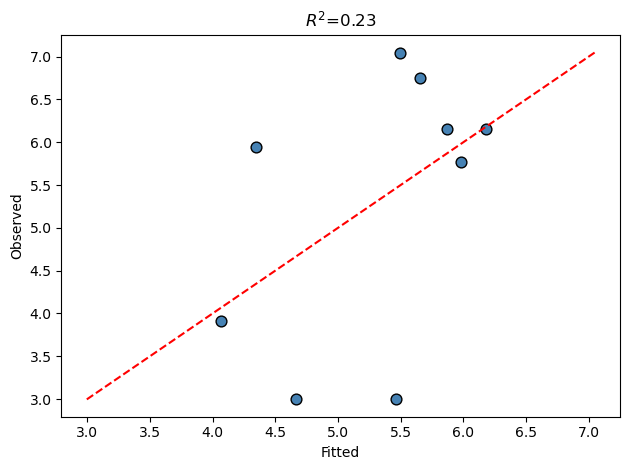

In [16]:
# GD방호성능 Regression
x1_col, x2_col, y_col = pairs[2]

formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col}") + Q("{x2_col}")'
)
print(formula)

model_GD = smf.ols(formula, data = df)

result_GD = model_GD.fit()
pred_GD = result_GD.predict()
print('pred_GD:', pred_GD)
print(result_GD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_GD = df[y_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

plt.tight_layout()
plt.show()

Q("log_HD") ~ Q("평량(g/m2)") + Q("BET(m2/g)")
pred_HD: [6.27404169 6.01908865 5.02690716 5.44558956 6.76596016 4.93559327
 2.06259934 2.89971493 1.48020844]
                            OLS Regression Results                            
Dep. Variable:            Q("log_HD")   R-squared:                       0.830
Model:                            OLS   Adj. R-squared:                  0.774
Method:                 Least Squares   F-statistic:                     14.69
Date:                Fri, 01 May 2026   Prob (F-statistic):            0.00488
Time:                        13:47:05   Log-Likelihood:                -10.973
No. Observations:                   9   AIC:                             27.95
Df Residuals:                       6   BIC:                             28.54
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


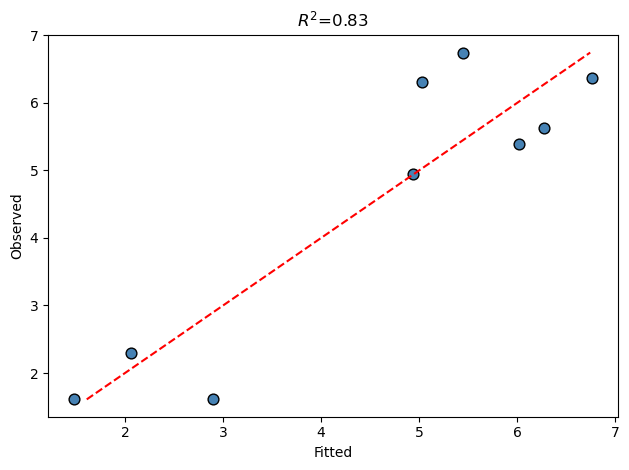

In [17]:
# HD방호성능 Regression
x1_col, x2_col, y_col = pairs[3]

formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col}") + Q("{x2_col}")'
)
print(formula)

model_HD = smf.ols(formula, data = df)

result_HD = model_HD.fit()
pred_HD = result_HD.predict()
print('pred_HD:', pred_HD)
print(result_HD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_HD = df[y_col]

ax.scatter(pred_HD, true_y_HD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_HD.min(), true_y_HD.max()], [true_y_HD.min(), true_y_HD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_HD.rsquared:.2f}')

plt.tight_layout()
plt.show()

# logx, logy

Q("SWATCH(GD) 24h(Con)") ~ Q("log평량") + Q("BET(m2/g)")
pred_GD: [556.70056864 515.56434041 457.78129443 477.06394529 607.74936567
 457.92243461 265.45470752 295.09713186  96.66621157]
                               OLS Regression Results                               
Dep. Variable:     Q("SWATCH(GD) 24h(Con)")   R-squared:                       0.179
Model:                                  OLS   Adj. R-squared:                 -0.095
Method:                       Least Squares   F-statistic:                    0.6531
Date:                      Fri, 01 May 2026   Prob (F-statistic):              0.554
Time:                              13:50:57   Log-Likelihood:                -64.953
No. Observations:                         9   AIC:                             135.9
Df Residuals:                             6   BIC:                             136.5
Df Model:                                 2                                         
Covariance Type:                  nonrobust        

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


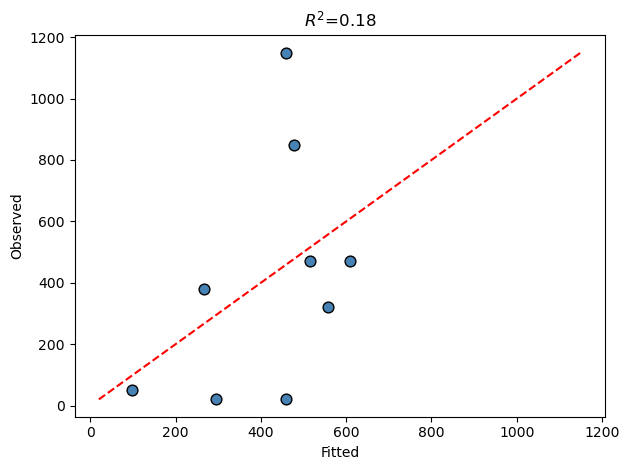

In [5]:
# GD방호성능 Regression
x1_col, x2_col, y_col = pairs[0]
df['log평량'] = np.log(df[x1_col])
df['log_GD'] = np.log(df[y_col])

x1_col_log = 'log평량'
formula = (
    f'Q("{y_col}") ~ '
    f'Q("{x1_col_log}") + Q("{x2_col}")'
)
print(formula)

model_GD = smf.ols(formula, data = df)

result_GD = model_GD.fit()
pred_GD = result_GD.predict()
print('pred_GD:', pred_GD)
print(result_GD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_GD = df[y_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

plt.tight_layout()
plt.show()

Q("log_GD") ~ Q("log평량") + Q("BET(m2/g)")
pred_GD: [6.0141201  5.96751359 5.4488284  5.6532594  6.22166254 5.40565776
 4.34283338 4.61337784 4.04294574]
                            OLS Regression Results                            
Dep. Variable:            Q("log_GD")   R-squared:                       0.249
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9968
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.423
Time:                        13:51:02   Log-Likelihood:                -15.021
No. Observations:                   9   AIC:                             36.04
Df Residuals:                       6   BIC:                             36.63
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t

c:\Programming\Anaconda\Lib\site-packages\scipy\stats\_stats_py.py:1971: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  k, _ = kurtosistest(a, axis)


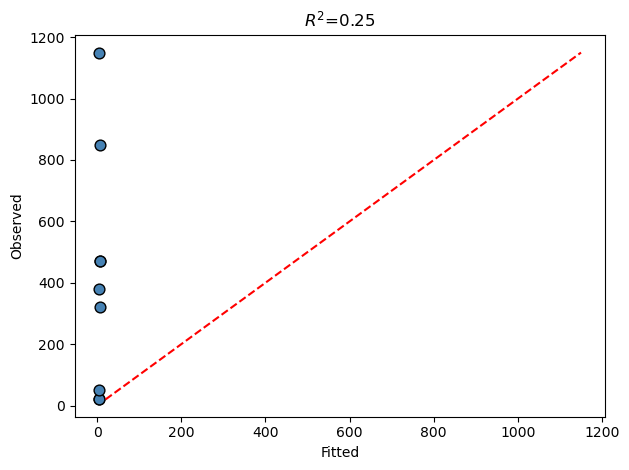

In [6]:
# GD방호성능 Regression
x1_col, x2_col, y_col = pairs[0]


x1_col_log = 'log평량'
y_col_log = 'log_GD'

formula = (
    f'Q("{y_col_log}") ~ '
    f'Q("{x1_col_log}") + Q("{x2_col}")'
)
print(formula)

model_GD = smf.ols(formula, data = df)

result_GD = model_GD.fit()
pred_GD = result_GD.predict()
print('pred_GD:', pred_GD)
print(result_GD.summary())

# Pred vs. Observed
fig, ax = plt.subplots()

true_y_GD = df[y_col]

ax.scatter(pred_GD, true_y_GD, color='steelblue', edgecolors='black', s=60)

# 기준선
ax.plot([true_y_GD.min(), true_y_GD.max()], [true_y_GD.min(), true_y_GD.max()],
        linestyle='--', color='red')
# for idx, (xi, yi) in enumerate(zip(pred_GD, true_y_GD)):
#     ax.annotate(samples[idx], (xi, yi),
#                 fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('Fitted')
ax.set_ylabel('Observed')
ax.set_title(f'$R^{2}$={result_GD.rsquared:.2f}')

plt.tight_layout()
plt.show()